In [3]:
import os
import shutil
import random
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, classification_report

# Split the Data into Train, Validation, and Test Sets

In [8]:
# Paths
source_dir = "disaster_dataset" # Your folder with the disaster categories
target_dir = "disaster_data_split"

# Create folder structure if it doesn't exist
if os.path.exists(target_dir):
    shutil.rmtree(target_dir) # remove existing directory to ensure a fresh split

for split in ["train", "valid", "test"]:
    for category in ["cyclone", "earthquake", "flood", "wildfire"]:
        os.makedirs(os.path.join(target_dir, split, category), exist_ok=True)

# Split ratios
train_ratio = 0.7
valid_ratio = 0.2
test_ratio = 0.1

# List of categories
categories = ["cyclone", "earthquake", "flood", "wildfire"]

for category in categories:
    files = os.listdir(os.path.join(source_dir, category))
    random.shuffle(files)
    
    n_total = len(files)
    n_train = int(n_total * train_ratio)
    n_valid = int(n_total * valid_ratio)
    
    train_files = files[:n_train]
    valid_files = files[n_train : n_train + n_valid]
    test_files = files[n_train + n_valid:]
    
    # Copy files to the respective directories
    for f in train_files:
        shutil.copy(os.path.join(source_dir, category, f),
                    os.path.join(target_dir, "train", category, f))
        
    for f in valid_files:
        shutil.copy(os.path.join(source_dir, category, f),
                    os.path.join(target_dir, "valid", category, f))
        
    for f in test_files:
        shutil.copy(os.path.join(source_dir, category, f),
                    os.path.join(target_dir, "test", category, f))

print("✅ Data split completed!")

✅ Data split completed!


##  Load VGG16 for Feature Extraction

In [10]:
# Image parameters
img_height, img_width = 224, 224
batch_size = 32

# Load VGG16 model, excluding the top classification layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

# Create a new model that outputs the features from the base model
model = Model(inputs=base_model.input, outputs=base_model.output)

# Data Generator
datagen = ImageDataGenerator(rescale=1./255)

# Function to extract features
def extract_features(directory):
    features = []
    labels = []
    generator = datagen.flow_from_directory(
        directory,
        target_size=(img_height, img_width),
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=False
    )
    
    for inputs_batch, labels_batch in generator:
        features_batch = model.predict(inputs_batch)
        features.append(features_batch.reshape(features_batch.shape[0], -1))
        labels.append(labels_batch)
        if len(features) * batch_size >= generator.n:
            break
            
    return np.concatenate(features), np.concatenate(labels)

# Extract features for train, validation, and test sets
train_features, train_labels = extract_features(os.path.join(target_dir, "train"))
valid_features, valid_labels = extract_features(os.path.join(target_dir, "valid"))
test_features, test_labels = extract_features(os.path.join(target_dir, "test"))

# Convert one-hot encoded labels to single integer labels for XGBoost
train_labels_xgb = np.argmax(train_labels, axis=1)
valid_labels_xgb = np.argmax(valid_labels, axis=1)
test_labels_xgb = np.argmax(test_labels, axis=1)

print("✅ Feature extraction completed!")

Found 3097 images belonging to 4 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━

# Train and Evaluate the XGBoost Classifier

In [11]:
# Initialize and train the XGBoost classifier
xgb_classifier = xgb.XGBClassifier(objective='multi:softmax', 
                                   num_class=4,
                                   eval_metric='mlogloss')

print("Training XGBoost model...")
xgb_classifier.fit(train_features, train_labels_xgb)

# Evaluate on the validation set
print("\n--- Validation Set Evaluation ---")
val_accuracy = xgb_classifier.score(valid_features, valid_labels_xgb)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

# Evaluate on the test set
print("\n--- Test Set Evaluation ---")
test_accuracy = xgb_classifier.score(test_features, test_labels_xgb)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Training XGBoost model...

--- Validation Set Evaluation ---
Validation Accuracy: 91.63%

--- Test Set Evaluation ---
Test Accuracy: 90.60%


## Conclusion: The  model looks well-trained and not overfitted.

# Performance Visualization


--- Classification Report ---
              precision    recall  f1-score   support

     cyclone       0.93      0.96      0.94        94
  earthquake       0.88      0.94      0.91       136
       flood       0.92      0.81      0.86       108
    wildfire       0.92      0.92      0.92       109

    accuracy                           0.91       447
   macro avg       0.91      0.91      0.91       447
weighted avg       0.91      0.91      0.91       447


--- Confusion Matrix ---


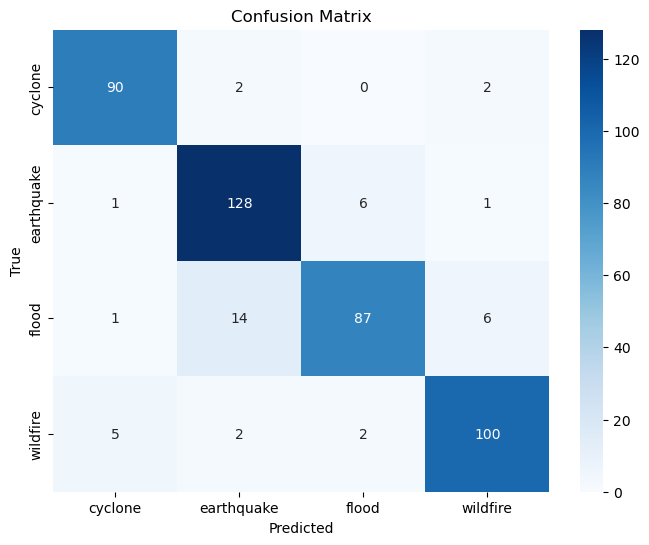

In [12]:
# Get predictions for the test set
test_predictions = xgb_classifier.predict(test_features)

# Classification Report
print("\n--- Classification Report ---")
print(classification_report(test_labels_xgb, test_predictions, target_names=categories))

# Confusion Matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(test_labels_xgb, test_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Save the  Trained Models

In [13]:
#VGG16 feature extractor model 
model.save("vgg16_feature_extractor.h5") 

# XGBoost classifier is named 'xgb_classifier'
import joblib
joblib.dump(xgb_classifier, 'xgb_classifier.pkl')

print("✅ Both VGG16 feature extractor and XGBoost models have been saved.")

✅ Both VGG16 feature extractor and XGBoost models have been saved.
